In [ ]:
!apt-get install ffmpeg -y
!ffmpeg -i "4K Road traffic video for object detection and tracking - free download now!_720p.mp4" -t 30 -c copy traffic_clip.mp4

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq -

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

model = YOLO('best.pt')
results = model.track(
    source='traffic_clip.mp4',
    persist=True,
    save=True
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 359ms
Prepared 1 package in 65ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos

In [1]:
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.download('/content/runs/detect/track/traffic_clip.avi')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np

cap = cv2.VideoCapture('traffic_clip.mp4')
ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, maxCorners=100, qualityLevel=0.3, minDistance=7)

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None)

    good_new = p1[st==1]
    good_old = p0[st==1]

    for new, old in zip(good_new, good_old):
        a, b = new.ravel()
        c, d = old.ravel()
        cv2.arrowedLine(frame, (int(c), int(d)), (int(a), int(b)), (0, 255, 0), 2)

    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)
    frame_count += 1
    if frame_count % 50 == 0:
        print(f"Processed frame {frame_count}")

print(f"Optical flow complete. Total frames: {frame_count}")

Processed frame 50
Processed frame 100
Processed frame 150
Processed frame 200
Processed frame 250
Processed frame 300
Processed frame 350
Processed frame 400
Processed frame 450
Processed frame 500
Processed frame 550
Processed frame 600
Processed frame 650
Processed frame 700
Processed frame 750
Processed frame 800
Processed frame 850
Processed frame 900
Optical flow complete. Total frames: 900


In [ ]:
import cv2
import numpy as np

cap = cv2.VideoCapture('traffic_clip.avi')
ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, maxCorners=100, qualityLevel=0.3, minDistance=7)

frame_count = 0
saved = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None)

    good_new = p1[st==1]
    good_old = p0[st==1]

    for new, old in zip(good_new, good_old):
        a, b = new.ravel()
        c, d = old.ravel()
        cv2.arrowedLine(frame, (int(c), int(d)), (int(a), int(b)), (0, 255, 0), 2)

    if frame_count in [10, 20, 30]:
        cv2.imwrite(f'optical_flow_frame_{frame_count}.jpg', frame)
        saved += 1
        print(f"Saved frame {frame_count}")

    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)
    frame_count += 1

print(f"Done. Saved {saved} screenshots.")

Saved frame 10
Saved frame 20
Saved frame 30
Done. Saved 3 screenshots.


In [2]:
from google.colab import files
uploaded = files.upload()

Saving traffic_clip.avi to traffic_clip.avi
Saving best.pt to best.pt


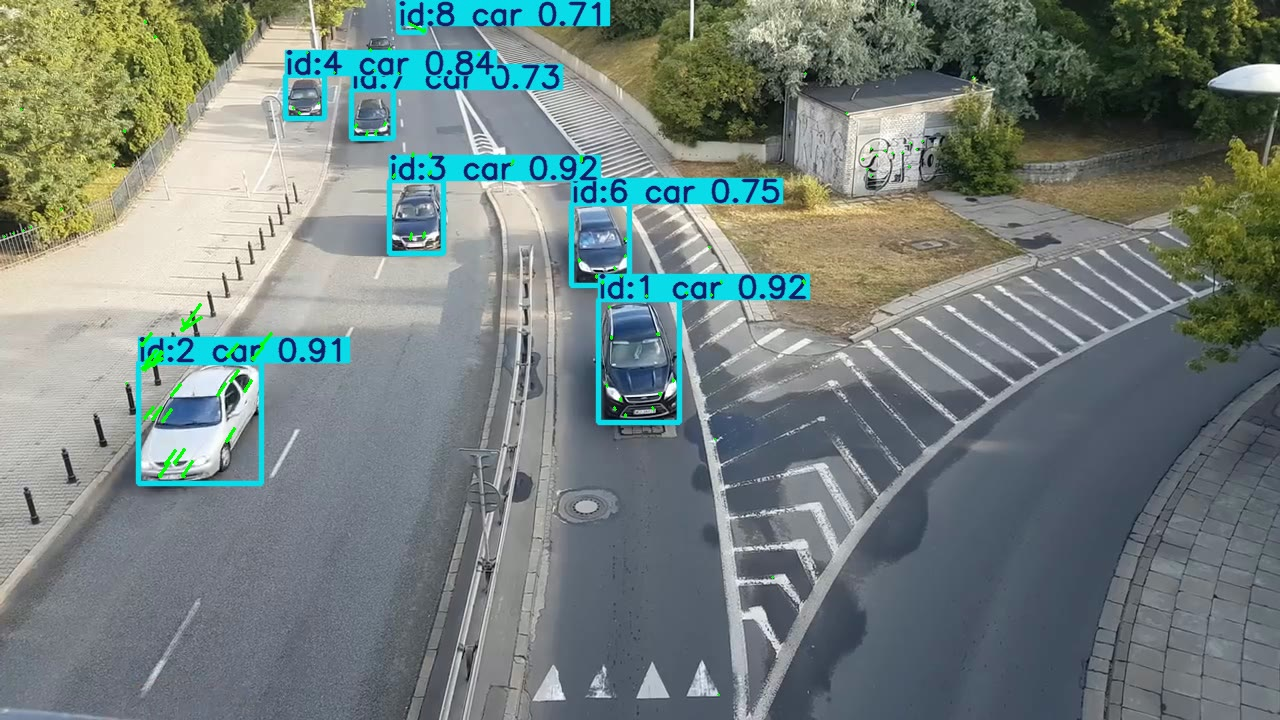

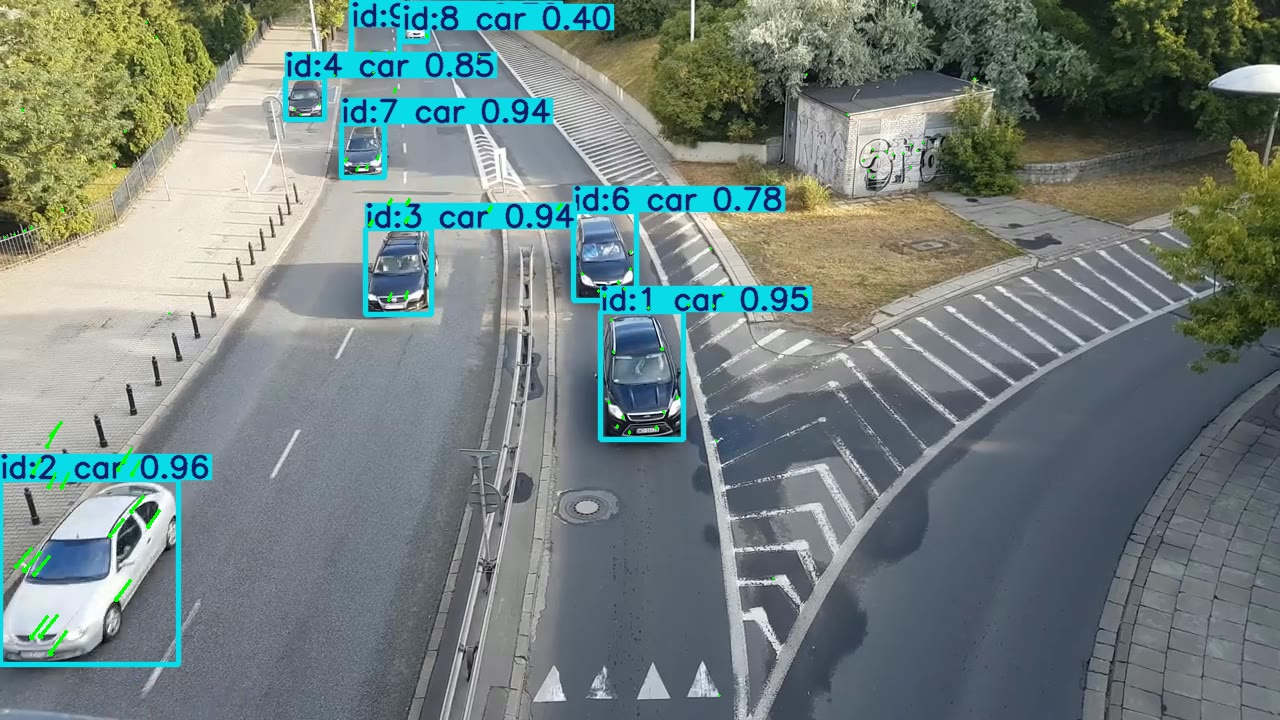

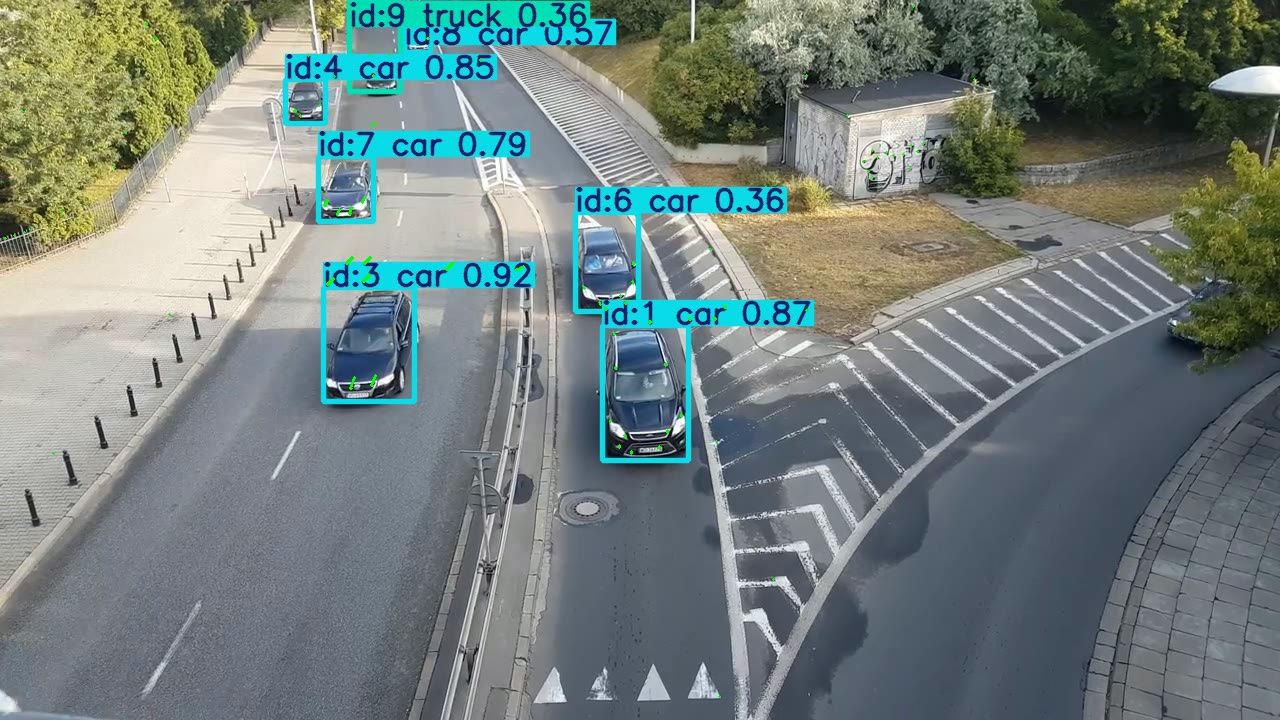

In [ ]:
from IPython.display import Image, display

display(Image('optical_flow_frame_10.jpg'))
display(Image('optical_flow_frame_20.jpg'))
display(Image('optical_flow_frame_30.jpg'))

In [ ]:
from google.colab import files
files.download('optical_flow_frame_10.jpg')
files.download('optical_flow_frame_20.jpg')
files.download('optical_flow_frame_30.jpg')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'optical_flow_frame_20.jpg', 'best.pt', 'optical_flow_frame_10.jpg', 'traffic_clip.avi', 'optical_flow_frame_30.jpg', 'sample_data']


In [3]:
from ultralytics import YOLO

model = YOLO('best.pt')

results = model.track(
    source='traffic_clip.avi',
    persist=True,
    save=True,
    project='tracking',
    name='run1'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 199ms
Prepared 1 package in 31ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r 

In [ ]:
import glob
from IPython.display import Image, display

tracking_frames = glob.glob('/content/runs/detect/tracking/run1/*.jpg')
print(f"Found {len(tracking_frames)} frames")
display(Image(tracking_frames[50]))

Found 0 frames


IndexError: list index out of range

In [ ]:
import os
print(os.listdir('/content/runs/detect/tracking/run1'))

['traffic_clip.avi']


In [ ]:
from google.colab import files
files.download('/content/runs/detect/tracking/run1/traffic_clip.avi')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

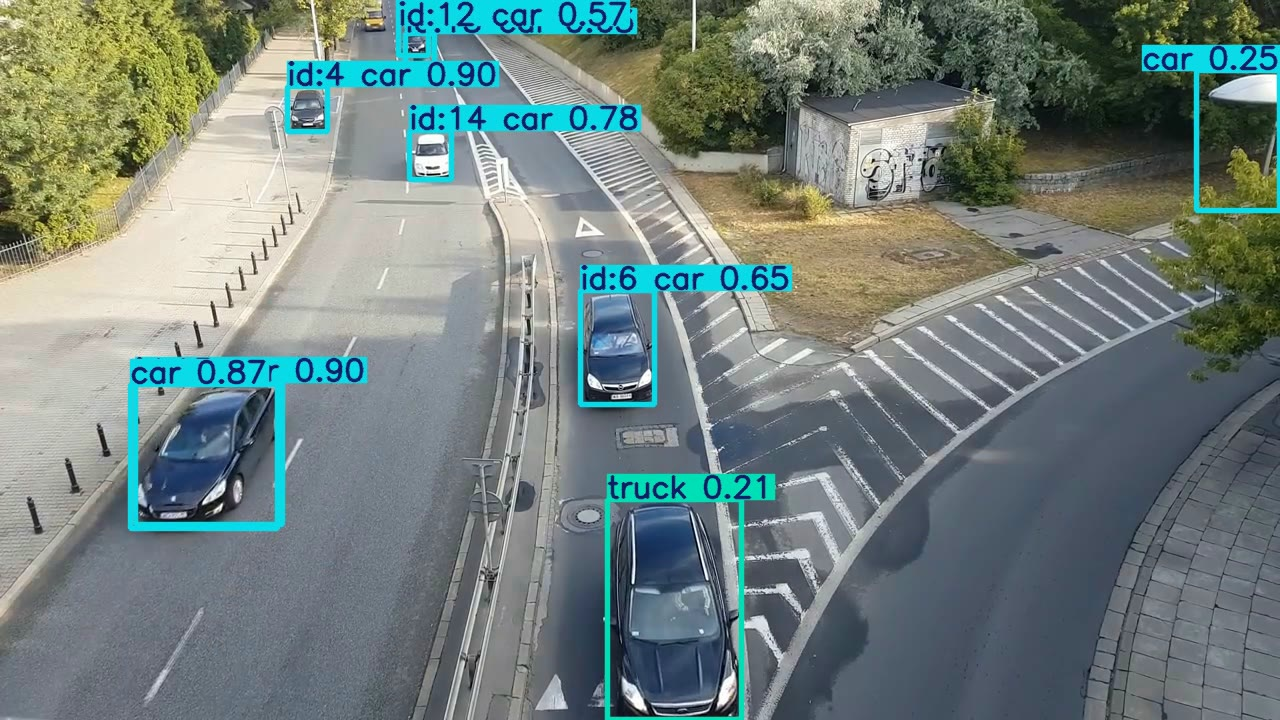

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import cv2

cap = cv2.VideoCapture('/content/runs/detect/tracking/run1/traffic_clip.avi')
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, frame = cap.read()
cv2.imwrite('tracking_sample.jpg', frame)
cap.release()

from IPython.display import Image, display
display(Image('tracking_sample.jpg'))
files.download('tracking_sample.jpg')